# Mefloquine v2

# Packages

In [135]:
from cmapPy.pandasGEXpress import parse
import itertools
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import random
import seaborn as sns
import scipy.spatial.distance as ssd
import scipy.cluster.hierarchy as sch
from tqdm import tqdm
import umap.umap_ as umap

import torch
from torch.nn import Linear, ReLU, Sequential
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.data import Batch
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.utils import from_networkx

# Directories

In [5]:
INPUT = 'D:/DDesktop/_work/data/canada/input/'
OUTPUT = 'D:/DDesktop/_work/data/canada/output/'

GRAPH = 'D:/DDesktop/_work/graphs/canada/'
CONTEXT = 'D:/DDesktop/_work/graphs/canada/context/'

# Functions

In [190]:
def graph_edge_weights(graph: nx.Graph, modifier: int = 1, report: bool = False) -> list:
    '''
    Extracts edge weight values of a NetworkX graph object to a list. A modifier converts the values for visualisation.
    '''

    weights = [graph[source][target]['weight'] / modifier for source, target, attr in graph.edges(data = True)]

    if report == True:
        num_entries = len(weights)
        print('>> graph_edge_getweights')
        print(f'Weights extracted for {num_entries:,} edges w/ a modifier of {modifier:,}')
        print()

    return weights

def pickle_load(path: str, report: bool = False):
    '''
    Loads pickled data.
    '''

    with open(path, 'rb') as f:
        data = pickle.load(f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_load')
            print(f'Pickled graph loaded w/ {num_nodes:,} nodes and {num_edges:,} edges')
            print()
        else:
            print('>> pickle_load')
            print(f'Pickled file loaded')
            print()

    return data

def pickle_save(path: str, data, report: bool = False):
    '''
    Pickles data.
    '''

    with open(path, 'wb') as f:
        pickle.dump(data, f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_save')
            print(f'Graph w/ {num_nodes:,} nodes and {num_edges:,} edges pickled')
        else:
            print('>> pickle_save')
            print(f'Data pickled')
            print()


# Processing

## STRING

### `df_string_edgelist`

In [45]:
# Load data
df_string_edgelist = pd.read_csv(INPUT + '9606.protein.physical.links.full.v12.0.txt.gz', compression = 'gzip', sep = ' ')

# Drop columns
df_string_edgelist = df_string_edgelist[['protein1', 'protein2', 'combined_score']]

# Remove taxon ID
for column in ['protein1', 'protein2']:
    df_string_edgelist[column] = df_string_edgelist[column].str.replace('9606.', '')

# Save data
pickle_save(OUTPUT + 'df_string_edgelist.pkl', df_string_edgelist)
# Show data
df_string_edgelist.head()

,protein1,protein2,combined_score
0,ENSP00000000233,ENSP00000257770,311
1,ENSP00000000233,ENSP00000226004,161
2,ENSP00000000233,ENSP00000434442,499
3,ENSP00000000233,ENSP00000262455,531
4,ENSP00000000233,ENSP00000303145,499


### `df_string_info`

In [5]:
# Load data
df_string_info = pd.read_csv(INPUT + '9606.protein.info.v12.0.txt.gz', compression = 'gzip', sep = '\t')

# Drop columns
df_string_info.drop(columns = 'protein_size', inplace = True)

# Remove taxon ID
df_string_info['#string_protein_id'] = df_string_info['#string_protein_id'].str.replace('9606.', '')

# Rename columns
for old, new in zip(list(df_string_info.columns), ['id', 'string_name', 'string_desc']):
    df_string_info.rename(columns = {old : new}, inplace = True)

# Save data
pickle_save(OUTPUT + 'df_string_info.pkl', df_string_info)
# Show data
df_string_info.head()

,id,string_name,string_desc
0,ENSP00000000233,ARF5,ADP-ribosylation factor 5; GTP-binding protein...
1,ENSP00000000412,M6PR,Cation-dependent mannose-6-phosphate receptor;...
2,ENSP00000001008,FKBP4,"Peptidyl-prolyl cis-trans isomerase FKBP4, N-t..."
3,ENSP00000001146,CYP26B1,Cytochrome P450 26B1; Involved in the metaboli...
4,ENSP00000002125,NDUFAF7,"Protein arginine methyltransferase NDUFAF7, mi..."


### `df_string`

In [49]:
# Load data
df_string_edgelist = pickle_load(OUTPUT + 'df_string_edgelist.pkl')
df_df_string_info = pickle_load(OUTPUT + 'df_string_info.pkl')

# Copy edgelist
df_string = df_string_edgelist.copy(deep = True)
# Isolate columns
df_string = df_string[['protein1', 'protein2', 'combined_score']]

# Rename columns for merge
df_string_info.rename(columns = {'id' : 'protein1'}, inplace = True)
# Merge
df_string = pd.merge(df_string, df_string_info[['protein1', 'string_name', 'string_desc']], how = 'left', on = 'protein1')
# Rename columns for merge
df_string_info.rename(columns = {'protein1' : 'protein2'}, inplace = True)
# Merge
df_string = pd.merge(df_string, df_string_info[['protein2', 'string_name', 'string_desc']], how = 'left', on = 'protein2')
# Reset column names
df_string_info.rename(columns = {'protein2' : 'id'}, inplace = True)

# Rename columns
old_names = df_string.columns
new_names = ['source_id', 'target_id', 'weight', 'source', 'source_annot', 'target', 'target_annot']
df_string.rename(columns = dict(zip(old_names, new_names)), inplace = True)

# # Remove taxon ID
# for column in ['source_id', 'target_id']:
#     df_string[column] = df_string[column].str.replace('9606.', '')

# Set column order
column_order = ['source', 'target', 'weight', 'source_id', 'target_id', 'source_annot', 'target_annot']
df_string = df_string[column_order]

# Save data
pickle_save(OUTPUT + 'df_string.pkl', df_string)
# Show data
df_string.head()

,source,target,weight,source_id,target_id,source_annot,target_annot
0,ARF5,NT5E,311,ENSP00000000233,ENSP00000257770,ADP-ribosylation factor 5; GTP-binding protein...,5'-nucleotidase; Hydrolyzes extracellular nucl...
1,ARF5,DUSP3,161,ENSP00000000233,ENSP00000226004,ADP-ribosylation factor 5; GTP-binding protein...,Dual specificity protein phosphatase 3; Shows ...
2,ARF5,ARFGAP2,499,ENSP00000000233,ENSP00000434442,ADP-ribosylation factor 5; GTP-binding protein...,ADP-ribosylation factor GTPase-activating prot...
3,ARF5,ERP44,531,ENSP00000000233,ENSP00000262455,ADP-ribosylation factor 5; GTP-binding protein...,Endoplasmic reticulum resident protein 44; Med...
4,ARF5,TMED10,499,ENSP00000000233,ENSP00000303145,ADP-ribosylation factor 5; GTP-binding protein...,Transmembrane emp24 domain-containing protein ...


## OPENtargets

### `df_opentargets`

In [6]:
# Load data
df_opentargets = pd.read_csv(INPUT + 'EFO_0007444-known-drugs.tsv', sep = '\t')

# Drop columns
df_opentargets.drop(columns = ['diseaseId', 'diseaseName'], inplace = True)
# Lower case
df_opentargets['drugName'] = df_opentargets['drugName'].str.lower()
# Rename columns
old_names = list(df_opentargets.columns)
new_names = ['drug_id', 'drug_name', 'drug_type', 'moa', 'moa_type', 'target_symbol', 'target_name', 'trial_phase', 'trial_status', 'source']

for old, new in zip(old_names, new_names):
    df_opentargets.rename(columns = {old : new}, inplace = True)

# Save data
pickle_save(OUTPUT + 'df_opentargets.pkl', df_opentargets)
# Show data
df_opentargets.head()

,drug_id,drug_name,drug_type,moa,moa_type,target_symbol,target_name,trial_phase,trial_status,source
0,CHEMBL112,acetaminophen,Small molecule,Anandamide amidohydrolase inhibitor,Inhibitor,FAAH,fatty acid amide hydrolase,3.0,Completed,https://clinicaltrials.gov/study/NCT02974348
1,CHEMBL112,acetaminophen,Small molecule,Cyclooxygenase inhibitor,Inhibitor,PTGS2,prostaglandin-endoperoxide synthase 2,3.0,Completed,https://clinicaltrials.gov/study/NCT02974348
2,CHEMBL112,acetaminophen,Small molecule,Cyclooxygenase inhibitor,Inhibitor,PTGS1,prostaglandin-endoperoxide synthase 1,3.0,Completed,https://clinicaltrials.gov/study/NCT02974348
3,CHEMBL112,acetaminophen,Small molecule,Vanilloid receptor opener,Opener,TRPV1,transient receptor potential cation channel su...,3.0,Completed,https://clinicaltrials.gov/study/NCT02974348
4,CHEMBL628,pentoxifylline,Small molecule,"3',5'-cyclic phosphodiesterase inhibitor",NaN,PDE4A,phosphodiesterase 4A,2.0,Terminated,https://clinicaltrials.gov/study/NCT00133393


## LINCS

### `df_lincs_info`

In [7]:
# Load data
df_lincs_info = pd.read_csv(INPUT + 'GSE92742_Broad_LINCS_sig_info.txt', sep = '\t')

# Rename columns
df_lincs_info.rename(columns = {'pert_id' : 'perturbagen_id', 'pert_iname' : 'perturbagen_name'}, inplace = True)

# Save data
pickle_save(OUTPUT + 'df_lincs_info.pkl', df_lincs_info)
# Show data
df_lincs_info.head()

C:\Users\roman\AppData\Local\Temp\ipykernel_31188\3478101401.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_lincs_info = pd.read_csv(INPUT + 'GSE92742_Broad_LINCS_sig_info.txt', sep = '\t')


,sig_id,perturbagen_id,perturbagen_name,pert_type,cell_id,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_time_unit,pert_itime,distil_id
0,AML001_CD34_24H:A05,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X1_F1B10:A05
1,AML001_CD34_24H:A06,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X3_F1B10:A06
2,AML001_CD34_24H:B05,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X1_F1B10:B05|AML001_CD34_24H_X...
3,AML001_CD34_24H:B06,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X3_F1B10:B06
4,AML001_CD34_24H:BRD-A03772856:0.37037,BRD-A03772856,BRD-A03772856,trt_cp,CD34,0.37037,µM,500 nM,24,h,24 h,AML001_CD34_24H_X1_F1B10:J04|AML001_CD34_24H_X...


#### `df_lincs_perturbagens`

In [8]:
# Load data
df_lincs_info = pickle_load(OUTPUT + 'df_lincs_info.pkl')

# Isolate columns
df_lincs_perturbagens = df_lincs_info[['perturbagen_id', 'perturbagen_name']].copy()
# Remove duplicates
df_lincs_perturbagens.drop_duplicates(inplace = True, ignore_index = True)

# Save data
pickle_save(OUTPUT + 'df_lincs_perturbagens.pkl', df_lincs_perturbagens)
# Show data
df_lincs_perturbagens.head()

,perturbagen_id,perturbagen_name
0,DMSO,DMSO
1,BRD-A03772856,BRD-A03772856
2,BRD-A19037878,trichostatin-a
3,BRD-A19500257,geldanamycin
4,BRD-A34037822,KUC107191N


### `df_lincs_genes`

In [9]:
# Load data
df_lincs_genes = pd.read_csv(INPUT + 'GSE92742_Broad_LINCS_gene_info.txt', sep = '\t')

# Rename columns
old_names = ['pr_gene_id', 'pr_gene_symbol', 'pr_gene_title', 'pr_is_lm', 'pr_is_bing']
new_names = ['rid', 'lincs_name', 'lincs_desc', 'landmark', 'inferred']

for old, new in zip(old_names, new_names):
    df_lincs_genes.rename(columns = {old : new}, inplace = True)

# Save data
pickle_save(OUTPUT + 'df_lincs_genes.pkl', df_lincs_genes)
# Show data
df_lincs_genes.head()

,rid,lincs_name,lincs_desc,landmark,inferred
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


#### `df_lincs_landmark`

In [10]:
# Load data
df_lincs_landmark = pickle_load(OUTPUT + 'df_lincs_genes.pkl')

# Filter data
df_lincs_landmark = df_lincs_landmark[df_lincs_landmark['landmark'] == 1]
# Drop columns
df_lincs_landmark = df_lincs_landmark[['rid', 'lincs_name', 'lincs_desc']].copy()

# Save data
pickle_save(OUTPUT + 'df_lincs_landmark.pkl', df_lincs_landmark)
# Show data
df_lincs_landmark.head()

,rid,lincs_name,lincs_desc
0,780,DDR1,discoidin domain receptor tyrosine kinase 1
1,7849,PAX8,paired box 8
25,6193,RPS5,ribosomal protein S5
43,23,ABCF1,ATP binding cassette subfamily F member 1
49,9552,SPAG7,sperm associated antigen 7


# Analysis

## LINCS

### `df_lincs_signatures`

In [ ]:
# Filters
FILTER_CELLS = ['HT29']
FILTER_TIMEPOINTS = [6]
FILTER_DOSES = [10]

# Load data
df_lincs_info = pickle_load(OUTPUT + 'df_lincs_info.pkl')

# Filter data
df_filter = df_lincs_info[(df_lincs_info['cell_id'].isin(FILTER_CELLS)) &
                          (df_lincs_info['pert_time'].isin(FILTER_TIMEPOINTS)) &
                          (df_lincs_info['pert_dose'].isin(FILTER_DOSES))]

# Report
print(f'Cell(s): {FILTER_CELLS}')
print(f'Timepoint(s): {FILTER_TIMEPOINTS}')
print(f'Dose(s): {FILTER_DOSES}')
print()
num_perturbagens = len(pd.unique(df_filter['perturbagen_id']))
print(f'{num_perturbagens:,} unique perturbagens found after filtering')

# Extract signature IDs
df_lincs_signatures = pd.DataFrame(df_filter['sig_id'], columns = ['sig_id'])
df_lincs_signatures.reset_index(inplace = True, drop = True)

# Save data
pickle_save(OUTPUT + 'df_lincs_signatures.pkl', df_lincs_signatures)

# Show data
df_lincs_signatures.head()

Cell(s): ['HT29']
Timepoint(s): [6]
Dose(s): [10]

5,045 unique perturbagens found after filtering


,sig_id
0,CPC004_HT29_6H:BRD-A00546892-001-01-8:10
1,CPC004_HT29_6H:BRD-A00993607-003-15-4:10
2,CPC004_HT29_6H:BRD-A01593789-001-02-3:10
3,CPC004_HT29_6H:BRD-A01643550-001-03-1:10
4,CPC004_HT29_6H:BRD-A02006392-001-09-9:10


### `df_lincs`

In [22]:
# Load data
df_lincs_signatures = pickle_load(OUTPUT + 'df_lincs_signatures.pkl')
df_lincs_genes = pickle_load(OUTPUT + 'df_lincs_genes.pkl')
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')

# Extract signature IDs
list_ids = list(pd.unique(df_lincs_signatures['sig_id']))

# Filter LINCS data
df_lincs = parse.parse(INPUT + 'LDS-1481_1.0.gctx', cid = list_ids).data_df

# Initialise dataframe
df_lincs_meta = pd.DataFrame(list(df_lincs.columns), columns = ['cid'])
# Copy column
df_lincs_meta['metadata'] = df_lincs_meta['cid']
# Extract perturbagen ID
df_lincs_meta['metadata'] = df_lincs_meta['metadata'].str.replace(r'-(?:[^-]+-){2}[^-]+(?=:\d+$)', '', regex = True)
# Split metadata column
df_lincs_meta[['data', 'perturbagen_id', 'dose']] = df_lincs_meta['metadata'].str.split(':', expand = True)
# Split data column
df_lincs_meta[['dataset', 'cell_line', 'timepoint']] = df_lincs_meta['data'].str.split('_', expand = True)
# Drop columns
df_lincs_meta.drop(columns = ['metadata', 'data'], inplace = True)
# Merge data
df_lincs_meta = pd.merge(df_lincs_meta, df_lincs_perturbagens, how = 'left', on = 'perturbagen_id')

# Reset index
df_lincs.reset_index(inplace = True)
# Assert datatypes
df_lincs['rid'] = df_lincs['rid'].astype(int)
df_lincs_genes['rid'] = df_lincs_genes['rid'].astype(int)

# Merge
df_lincs = pd.merge(df_lincs, df_lincs_genes[['rid', 'lincs_name', 'lincs_desc', 'landmark']], how = 'left', on = 'rid')
# Melt on gene expression values
df_lincs = df_lincs.melt(id_vars = ['rid', 'lincs_name', 'lincs_desc', 'landmark'], var_name = 'cid', value_name = 'value')
# Merge with metadata
df_lincs = pd.merge(df_lincs, df_lincs_meta, how = 'left', on = 'cid')
# Reorder columns
df_lincs = df_lincs[['cid', 'dataset', 'cell_line', 'perturbagen_id', 'perturbagen_name', 'dose', 'timepoint', 'rid', 'lincs_name', 'lincs_desc', 'landmark', 'value']]
# Rename columns
df_lincs.rename(columns = {'rid' : 'gene_id', 'value' : 'dexp'}, inplace = True)

# Save data
pickle_save(OUTPUT + 'df_lincs_meta.pkl', df_lincs_meta)
pickle_save(OUTPUT + 'df_lincs.pkl', df_lincs)
# Show data
df_lincs.head()

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\cmapPy\pandasGEXpress\parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\cmapPy\pandasGEXpress\parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


,cid,dataset,cell_line,perturbagen_id,perturbagen_name,dose,timepoint,gene_id,lincs_name,lincs_desc,landmark,dexp
0,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,5720,PSME1,proteasome activator subunit 1,1,-2.999525
1,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,466,ATF1,activating transcription factor 1,1,-1.922989
2,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,6009,RHEB,Ras homolog enriched in brain,1,-0.742801
3,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,2309,FOXO3,forkhead box O3,1,-1.567428
4,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,387,RHOA,ras homolog family member A,1,-2.488176


In [23]:
df_lincs_meta.head()

,cid,perturbagen_id,dose,dataset,cell_line,timepoint,perturbagen_name
0,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,BRD-A85280935,10,CPC005,HT29,6H,quinpirole
1,CPC005_HT29_6H:BRD-A07824748-001-02-6:10,BRD-A07824748,10,CPC005,HT29,6H,flavanone
2,CPC004_HT29_6H:BRD-K20482099-001-01-1:10,BRD-K20482099,10,CPC004,HT29,6H,rutin
3,CPC005_HT29_6H:BRD-K62929068-001-03-3:10,BRD-K62929068,10,CPC005,HT29,6H,6-benzylaminopurine
4,CPC005_HT29_6H:BRD-K43405658-001-01-8:10,BRD-K43405658,10,CPC005,HT29,6H,tyrphostin-AG-527


## Graph

### `graph_base`

In [50]:
# Set filter
FILTER_SCORE = 0

# Load data
df_string = pickle_load(OUTPUT + 'df_string.pkl')

# Generate graph object
graph_base = nx.from_pandas_edgelist(df_string[df_string.columns[0:3]], source = 'source', target = 'target', edge_attr = 'weight')

# Record number of nodes and edges
num_nodes = len(graph_base.nodes)
num_edges = len(graph_base.edges)

# Filter by edge weights
graph_base.remove_edges_from([(source, target) for source, target, weight in graph_base.edges(data = 'weight') if weight < FILTER_SCORE])
# Remove unconnected nodes
graph_base.remove_nodes_from(list(nx.isolates(graph_base)))

# Record number of nodes and edges
num_nodes_filter = len(graph_base.nodes)
num_edges_filter = len(graph_base.edges)
# Calculate variables
percent_nodes = num_nodes_filter / num_nodes * 100
percent_edges = num_edges_filter / num_edges * 100

# Report
print(f'Base graph of {num_nodes:,} nodes and {num_edges:,} edges generated')
print(f'Filtered for edges with a confidence score >= {FILTER_SCORE}')
print(f'{percent_nodes:.2f}% nodes ({num_nodes_filter:,}/{num_nodes:,}) and {percent_edges:.2f}% edges ({num_edges_filter:,}/{num_edges:,}) remain')
print()

pickle_save(GRAPH + 'graph_base.pkl', graph_base)

Base graph of 18,767 nodes and 738,805 edges generated
Filtered for edges with a confidence score >= 0
100.00% nodes (18,767/18,767) and 100.00% edges (738,805/738,805) remain



### `graph_lm`

In [58]:
# Load graph
graph_base = pickle_load(GRAPH + 'graph_base.pkl')

# Load data
df_lincs_landmark = pickle_load(OUTPUT + 'df_lincs_landmark.pkl')

# Extract landmark gene IDs
list_landmark = list(pd.unique(df_lincs_landmark['lincs_name']))
# Extract nodelist
list_nodes = list(graph_base.nodes)
# Get landmark nodes not found in graph_base
list_missing = set(list_landmark) - set(list_nodes)
# Get overlapping landmark genes
list_overlap = set(list_landmark).intersection(set(list_nodes))

# Set nodes to remove
list_remove = set(list_nodes) - set(list_landmark)
# Copy graph
graph_lm = graph_base.copy()
# Remove nodes
graph_lm.remove_nodes_from(list_remove)
# Extract isolated nodes
list_isolates = list(nx.isolates(graph_lm))
# Remove unconnected nodes
graph_lm.remove_nodes_from(list_isolates)

# Calculate variables
len_landmark = len(list_landmark)
len_missing = len(list_missing)
len_overlap = len(list_overlap)
len_nodes = len(graph_base.nodes)
len_nodes_lm = len(graph_lm.nodes)
len_isolates = len(list_isolates)
percent_missing = len_missing / len_landmark * 100 
percent_overlap = len_overlap / len_landmark * 100
percent_isolates = len_isolates / len_overlap * 100
percent_nodes = len_nodes_lm / len_nodes * 100
percent_landmark = len_nodes_lm / len_landmark * 100

# Report
print(f'{len_landmark:,} landmark genes identified')
print(f'{percent_overlap:.2f}% of landmark genes ({len_overlap:,}/{len_landmark:,}) found in graph_base')
print(f'{percent_isolates:.2f}% of landmark genes ({len_isolates:,}/{len_overlap:,}) in subgraph found as isolates')
print(f'{percent_nodes:.2f}% of nodes ({len_nodes_lm:,}/{len_nodes:,}) remain after filtering graph_base for landmark nodes and removing isolates')
print(f'{percent_landmark:.2f}% of landmark genes ({len_nodes_lm:,}/{len_landmark:,}) retained in graph_lm')

# Get landmark genes missing from graph_base
df_missing = df_lincs_landmark[df_lincs_landmark['lincs_name'].isin(list_missing)].reset_index(drop = True)
# Get landmark genes flagged as isolates
df_isolates = df_lincs_landmark[df_lincs_landmark['lincs_name'].isin(list_isolates)].reset_index(drop = True)

# Save data
pickle_save(OUTPUT + 'df_missing.pkl', df_missing)
pickle_save(OUTPUT + 'df_isolates.pkl', df_isolates)

# Save graph
pickle_save(GRAPH + 'graph_lm.pkl', graph_lm)

978 landmark genes identified
97.03% of landmark genes (949/978) found in graph_base
2.95% of landmark genes (28/949) in subgraph found as isolates
4.91% of nodes (921/18,767) remain after filtering graph_base for landmark nodes and removing isolates
94.17% of landmark genes (921/978) retained in graph_lm


## Context Graph

### `df_perturbagens`

In [235]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')
df_opentargets = pickle_load(OUTPUT + 'df_opentargets.pkl')
df_lincs = pickle_load(OUTPUT + 'df_lincs.pkl')

# Get opentarget list
list_opentarget = list(pd.unique(df_opentargets['drug_name']))
# Add mefloquine to list
list_opentarget.append('mefloquine')
# Filter perturbagens
df_filter = df_lincs_perturbagens[df_lincs_perturbagens['perturbagen_name'].isin(list_opentarget)].copy()
# Drop duplicates
df_filter.drop_duplicates(subset = 'perturbagen_name', inplace = True)

# Report
num_opentarget = len(list_opentarget)
list_mapped = list(pd.unique(df_filter['perturbagen_name']))
num_mapped = len(list_mapped)
percent_mapped = num_mapped / num_opentarget * 100

set_opentarget = set(list_opentarget)
set_mapped = set(list_mapped)
set_missing = set_opentarget - set_mapped

print(f'{percent_mapped:.2f}% of opentarget drugs found in perturbagen data ({num_mapped:,}/{num_opentarget:,})')
print(f'opentarget: {set_opentarget}')
print(f'mapped: {set_mapped}')
print(f'missing: {set_missing}')

# Set extra perturbagen number
n = 500
# Extract perturbagen IDs and names from df_lincs
df_sample = df_lincs[['perturbagen_id', 'perturbagen_name']].copy()
# Remove duplicates
df_sample.drop_duplicates(inplace = True)
# Filter perturbagens
df_sample = df_sample[~df_sample['perturbagen_name'].isin(list_opentarget)]
# Sample random perturbagens
df_sample = df_sample.sample(n = n)

# # Filter perturbagens
# df_sample = df_lincs_perturbagens[~df_lincs_perturbagens['perturbagen_name'].isin(list_opentarget)]

# Report
print(f'{n:,} random perturbagens\' data added')

# Concatenate dataframes
df_perturbagens = pd.concat([df_filter, df_sample])

# Save data
pickle_save(OUTPUT + 'df_perturbagens.pkl', df_perturbagens)
# Show data
df_perturbagens.head()

62.50% of opentarget drugs found in perturbagen data (5/8)
opentarget: {'imatinib', 'agatolimod', 'pentoxifylline', 'mefloquine', 'rosiglitazone', 'imiquimod', 'acetaminophen', 'agatolimod sodium'}
mapped: {'imatinib', 'pentoxifylline', 'mefloquine', 'rosiglitazone', 'imiquimod'}
missing: {'acetaminophen', 'agatolimod sodium', 'agatolimod'}
500 random perturbagens' data added


,perturbagen_id,perturbagen_name
4868,BRD-A97437073,rosiglitazone
5424,BRD-K57569181,pentoxifylline
6339,BRD-K26657438,imiquimod
8044,BRD-K92723993,imatinib
9498,BRD-K40645748,mefloquine


### Context Graphs

In [236]:
# Load graph
graph_lm = pickle_load(GRAPH + 'graph_lm.pkl')
# Load data
df_lincs = pickle_load(OUTPUT + 'df_lincs.pkl')
df_perturbagens = pickle_load(OUTPUT + 'df_perturbagens.pkl')

# Extract perturbagen IDs
unique_perturbagens = list(pd.unique(df_perturbagens['perturbagen_id']))
unique_cells = list(pd.unique(df_lincs['cell_line']))
unique_timepoints = list(pd.unique(df_lincs['timepoint']))
unique_doses = list(pd.unique(df_lincs['dose']))

df_filter = df_lincs[df_lincs['perturbagen_id'].isin(unique_perturbagens)]

# Iterate through combinations of unique values
for cell_line, perturbagen_id, dose, timepoint in tqdm(itertools.product(unique_cells, unique_perturbagens, unique_doses, unique_timepoints), total = len(df_perturbagens), desc = 'Generating context graphs'):

    # Slice data
    df_slice = df_filter[(df_filter['cell_line'] == cell_line) &
                         (df_filter['perturbagen_id'] == perturbagen_id) &
                         (df_filter['dose'] == dose) &
                         (df_filter['timepoint'] == timepoint)]
    
    # Set index
    df_slice.set_index('lincs_name', inplace = True)

    # Extract columns
    df_slice = df_slice[['dexp']]

    # Copy graph_lm
    graph_slice = graph_lm.copy()
    # Set node attributes
    nx.set_node_attributes(graph_slice, df_slice['dexp'].to_dict(), name = 'dexp')

    # Save graph
    pickle_save(CONTEXT + f'{cell_line}_{perturbagen_id}_{dose}_{timepoint}.pkl', graph_slice)

Generating context graphs: 100%|██████████| 505/505 [09:37<00:00,  1.14s/it]


## GIN

- Run through GIN embedding
- Normalise embeddings
- Check cosine distances

- Compare with heatmap?

### Convert graphs to PyG objects

In [26]:
# Initialise graph list
pyg_graphs = []

# Iterate through files
for graph in tqdm(os.listdir(CONTEXT), desc = 'Converting context graphs to PyG objects', total = len(os.listdir(CONTEXT))):
    
    # Get perturbagen id
    perturbagen_id = graph.split('_')[1]
    
    # Load data
    G = pickle_load(CONTEXT + graph)
    # Iterate through nodes
    for node in G.nodes:
        G.nodes[node]['x'] = [G.nodes[node]['dexp']]
    
    # Convert to PyG object
    pyg = from_networkx(G)
    pyg.x = pyg.x.float()
    # Add perturbagen ID as name
    pyg.name = f'{perturbagen_id}'
    pyg_graphs.append(pyg)

Converting context graphs to PyG objects: 100%|██████████| 25/25 [00:07<00:00,  3.49it/s]


### GIN

In [43]:
# Define untrained GIN encoder
class GINEncoder(torch.nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        nn1 = Sequential(Linear(1, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        nn2 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)
        self.lin = Linear(hidden_dim, hidden_dim)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = global_add_pool(x, batch)
        return self.lin(x)

print('Untrained GIN encoder complete')

# Instantiate model
encoder = GINEncoder()
encoder.eval()

print('Model instantiated')

# Generate embeddings (no training)
embeddings = []
with torch.no_grad():
    for graph in tqdm(pyg_graphs, desc = 'Generating embeddings', total = len(pyg_graphs)):
        batch = torch.zeros(graph.x.size(0), dtype=torch.long)  # single graph batch
        emb = encoder(graph.x, graph.edge_index, batch)
        embeddings.append(emb.squeeze())

# Normalize embeddings
embedding_matrix = torch.stack(embeddings).numpy()
normed = embedding_matrix / np.linalg.norm(embedding_matrix, axis=1, keepdims=True)

print('Embeddings normalised')

# Set reference perturbagen ID
ref_name = 'BRD-K40645748'
# Find the index in pyg_graphs with defined ref_name
ref_idx = next(i for i, g in enumerate(pyg_graphs) if g.name == ref_name)

print('Calculating cosine similarities')

# Get cosine similarities to reference graph
sims = cosine_similarity([normed[ref_idx]], normed)[0]
# Get top 5, excluding itself
top_similar = sims.argsort()[::-1]
# Get .name values for these graphs
similar_names = [pyg_graphs[i].name for i in top_similar]
#print("Most similar to mefloquine graph:")
#for i, name in zip(top_similar, similar_names):
#    print(f"Index {i}: {name} (similarity = {sims[i]:.3f})")

Untrained GIN encoder complete
Model instantiated


Generating embeddings: 100%|██████████| 25/25 [00:00<00:00, 951.02it/s]

Embeddings normalised
Calculating cosine similarities


In [219]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')

# Convert ranked graphs to dataframe
df_similar = pd.DataFrame(similar_names, columns = ['perturbagen_id'])
# Merge
df_similar = pd.merge(df_similar, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')
# Show data
df_similar.head()

,perturbagen_id,perturbagen_name
0,BRD-K40645748,mefloquine
1,BRD-K92723993,imatinib
2,BRD-K09186736,BRD-K09186736
3,BRD-A43849199,karakoline
4,BRD-K59556282,BRD-K59556282


### Clustermap

In [68]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')

# Intialise dataframe
df_cluster = pd.DataFrame()

# Iterate through files
for graph in tqdm(os.listdir(CONTEXT), desc = 'Extracting expression values', total = len(os.listdir(CONTEXT))):
    
    # Get perturbagen id
    perturbagen_id = graph.split('_')[1]
    
    # Load data
    G = pickle_load(CONTEXT + graph)

    # Extract values
    dexp = [(node, G.nodes[node]['dexp']) for node in G.nodes]
    # Convert to dataframe
    df_dexp = pd.DataFrame(dexp, columns = ['node', 'dexp'])
    # Add perturbagen ID column
    df_dexp['perturbagen_id'] = perturbagen_id
    # Merge with df_lincs_perturbagens
    df_dexp = pd.merge(df_dexp, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')
    # Concatenate
    df_cluster = pd.concat([df_cluster, df_dexp])

df_cluster.head()

Extracting expression values:   0%|          | 0/25 [00:00<?, ?it/s]

Extracting expression values: 100%|██████████| 25/25 [00:00<00:00, 48.28it/s]


,node,dexp,perturbagen_id,perturbagen_name
0,DUSP3,0.087986,BRD-A17535965,gelsemine
1,TMED10,0.420787,BRD-A17535965,gelsemine
2,BLVRA,-0.300026,BRD-A17535965,gelsemine
3,FAS,-0.580968,BRD-A17535965,gelsemine
4,ERBB2,-1.193469,BRD-A17535965,gelsemine


c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


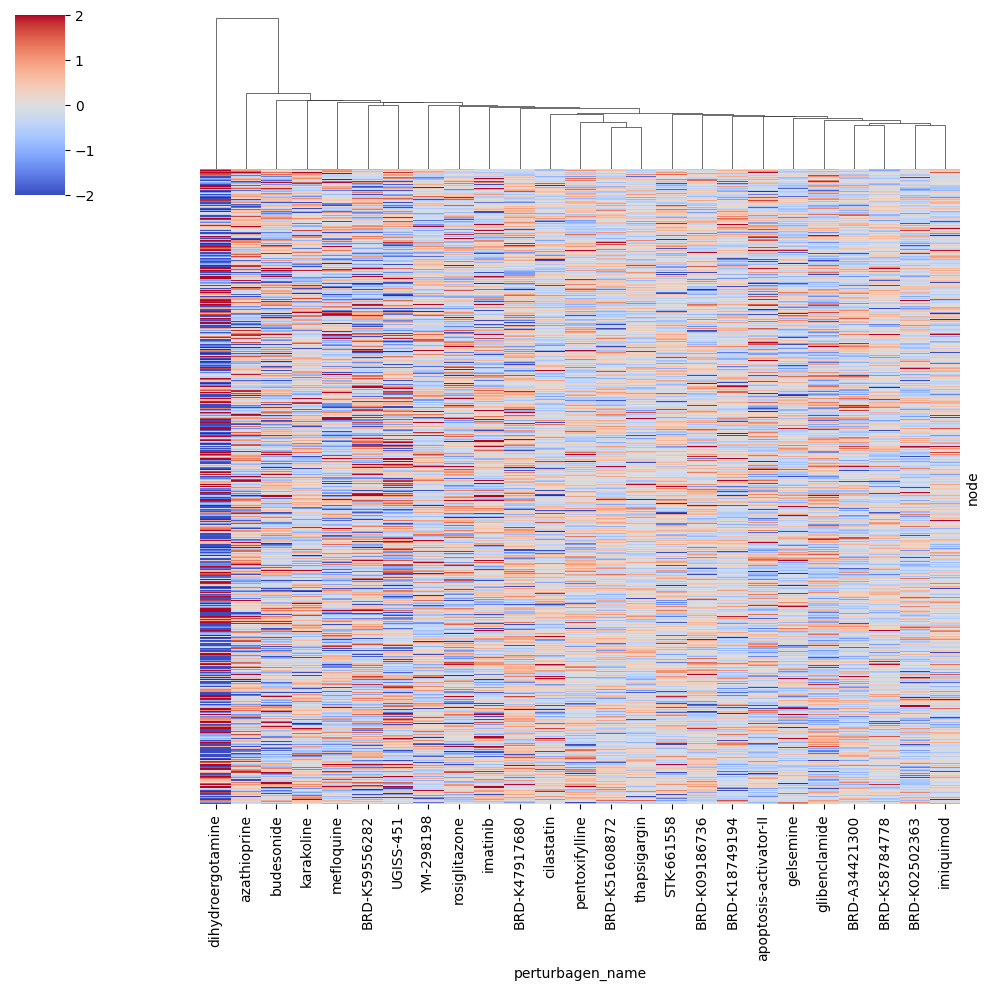

In [96]:
df_plot = pd.pivot(df_cluster, columns = 'perturbagen_name', index = 'node', values = 'dexp')

# Plot
sns.clustermap(df_plot,
               cmap = 'coolwarm', 
               vmin = -2, vmax = 2,
               row_cluster = False,
               col_cluster = True,
               metric = 'euclidean', method = 'average',
               yticklabels = False)

In [98]:
# Transpose so each graph/column becomes a row
data = df_plot.T

# Calculate cosine similarity matrix
similarity_matrix = cosine_similarity(data.values)

# Convert to DataFrame 
similarity_df = pd.DataFrame(similarity_matrix, index=data.index, columns=data.index)

# Define reference column
ref_col = 'mefloquine'
similarities = similarity_df.loc[ref_col].drop(ref_col).sort_values(ascending=False)

print(similarities)

perturbagen_name
UGISS-451                 0.327277
BRD-K59556282             0.235182
dihydroergotamine         0.234661
glibenclamide             0.224835
apoptosis-activator-II    0.216429
azathioprine              0.211664
budesonide                0.171650
BRD-K18749194             0.159245
BRD-K02502363             0.102310
imatinib                  0.094577
gelsemine                 0.088385
BRD-A34421300             0.074605
YM-298198                 0.071800
imiquimod                 0.069771
STK-661558                0.067125
BRD-K09186736             0.052005
rosiglitazone             0.037671
cilastatin                0.011664
karakoline                0.007169
BRD-K58784778             0.006168
BRD-K47917680            -0.037976
BRD-K51608872            -0.068048
pentoxifylline           -0.073283
thapsigargin             -0.088884
Name: mefloquine, dtype: float64


### uMAP

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


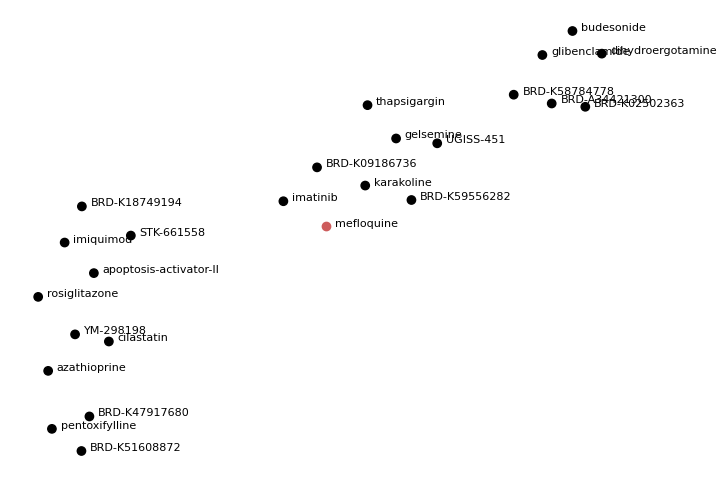

In [225]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')

# Get embeddings as a matrix
embedding_matrix = torch.stack(embeddings).numpy()
# Normalise embedding values
embedding_matrix = embedding_matrix / np.linalg.norm(embedding_matrix, axis=1, keepdims=True)

# Instantiate model
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(embedding_matrix)

# Set colors
colors = ['indianred' if g.name == 'BRD-K40645748' else 'black' for g in pyg_graphs]

plt.figure(figsize=(8, 6))
plt.axis('off')
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=colors)
for i, g in enumerate(pyg_graphs):
    pid = g.name
    pname = df_lincs_perturbagens['perturbagen_name'][df_lincs_perturbagens['perturbagen_id'] == pid].values[0]
    plt.text(embedding_2d[i, 0] + 0.1, embedding_2d[i, 1], f'{pname}', fontsize=8)

Absolute difference between mefloquine dexp values and dexp values of all other drugs?
Overlay absolute difference onto network visualisation (possibly hexbin), compare to 'closest' embedding and 'furthest' embedding.
Precursor to PGExplainer? This would require classifier model to identify 'similar' graphs 

### Absolute differences

In [172]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')

# Intialise dataframe
df_diff = pd.DataFrame()

# Iterate through files
for graph in tqdm(os.listdir(CONTEXT), desc = 'Extracting expression values', total = len(os.listdir(CONTEXT))):
    
    # Get perturbagen id
    perturbagen_id = graph.split('_')[1]
    
    # Load data
    G = pickle_load(CONTEXT + graph)

    # Extract values
    dexp = [(node, G.nodes[node]['dexp']) for node in G.nodes]
    # Convert to dataframe
    df_dexp = pd.DataFrame(dexp, columns = ['node', 'dexp'])
    # Add perturbagen ID column
    df_dexp['perturbagen_id'] = perturbagen_id
    # Merge with df_lincs_perturbagens
    df_dexp = pd.merge(df_dexp, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')
    # Concatenate
    df_diff = pd.concat([df_diff, df_dexp])

# Pivot
df_diff = pd.pivot(df_diff[['perturbagen_id', 'node', 'dexp']], index = 'node', columns = 'perturbagen_id', values = 'dexp')
# Define dataframe
df_abs = df_diff[['BRD-K40645748']].copy()
# Get remaining columns
list_columns = [column for column in df_diff.columns if column != 'BRD-K40645748']

# Iterate through columns
for column in tqdm(list_columns, desc = 'Calculating absolute difference', total = len(list_columns)):
    df_abs[column] = (df_abs['BRD-K40645748'] - df_diff[column]).abs()

# Drop mefloquine column
df_abs.drop(columns = ['BRD-K40645748'], inplace = True)

# Show data
df_abs.head()

Calculating absolute difference: 100%|██████████| 24/24 [00:00<00:00, 3225.77it/s]


perturbagen_id,BRD-A17535965,BRD-A34421300,BRD-A43849199,BRD-A54845972,BRD-A82238138,BRD-A90311807,BRD-A97437073,BRD-K02502363,BRD-K09186736,BRD-K15164005,...,BRD-K36927236,BRD-K47917680,BRD-K51608872,BRD-K57569181,BRD-K58784778,BRD-K59556282,BRD-K59650319,BRD-K69023402,BRD-K92723993,BRD-K96274284
node,,,,,,,,,,,,,,,,,,,,,
ABCB6,1.526952,1.180024,2.188705,0.331692,1.771642,0.222355,1.775782,1.639664,1.727686,1.256863,...,1.829606,0.830379,0.799019,0.793527,1.988364,0.243261,0.914301,1.437881,1.326165,0.433834
ABCC5,0.037456,0.013024,0.445489,9.177466,2.853546,0.165170,0.659157,0.066922,1.485414,0.210458,...,0.700544,1.299665,1.503235,0.088211,3.218285,0.056075,0.497022,0.394586,1.757055,3.651777
ABCF1,1.269906,1.401129,0.931434,1.401666,0.888402,1.856958,0.933133,1.112608,1.254653,0.275321,...,0.905328,1.277360,0.391658,0.061213,2.125990,1.295926,0.810089,1.630920,1.291132,0.394031
ABCF3,0.397323,0.469934,1.295103,0.568010,1.114727,1.305336,1.548055,1.179843,0.873104,0.004887,...,0.293929,1.429587,1.122422,1.232742,0.523276,0.416999,1.947700,1.421263,1.259449,1.035874
ABHD4,0.977585,0.315253,3.492848,6.016291,0.961078,0.387400,1.044387,0.355253,0.458658,1.502220,...,0.843270,0.904133,0.522628,1.077245,0.468889,0.089419,0.310463,0.988174,1.141702,1.337287


In [212]:
df_abs['BRD-K15164005'].sort_values()

node
BHLHE40    0.001856
EPN2       0.002211
EML3       0.002416
MAP2K5     0.003656
TBXA2R     0.004662
             ...   
E2F2       4.517789
HMGCS1     4.716782
CXCL2      4.854530
CCDC86     5.263272
HMOX1      7.805404
Name: BRD-K15164005, Length: 921, dtype: float64

In [176]:
# Get list of summed abs values for each perturbagen
list_abs_sorted_ids = df_abs.sum().sort_values().index.tolist()

In [ ]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')
# Load reference graph
graph_mef = pickle_load(CONTEXT + 'HT29_BRD-K40645748_10_6H.pkl')
# Generate positional data
pos = nx.spring_layout(graph_mef, k = 1.75)
# Convert to dataframe
df_hexbin = pd.DataFrame.from_dict(pos, orient = 'index', columns = ['x', 'y'])

# Load test graph
graph_test = pickle_load(CONTEXT + 'HT29_BRD-A34421300_10_6H.pkl')
# Add abs value as node attribute
df_attr = df_abs[['BRD-A34421300']]
# Copy df_hexbin
df_plot = df_hexbin.copy()
# Add values to df_hexbin
df_plot['values'] = df_attr.iloc[:,0]

# Calculate extend
x_min, x_max = df_hexbin['x'].min(), df_hexbin['x'].max()
y_min, y_max = df_hexbin['y'].min(), df_hexbin['y'].max()
extent = [x_min, x_max, y_min, y_max]

# Set variables
gridsize = 35
maxcount = 10

# Plot
fig, ax = plt.subplots(figsize = (10,10))
plt.axis('off')
ax.set_aspect('equal')

# Background
df_hexbin.plot.hexbin(x = 'x', y = 'y',
                      gridsize = gridsize, extent = extent,
                      mincnt = 1,
                      cmap = ListedColormap(['whitesmoke']), colorbar = False,
                      edgecolors = 'gainsboro',
                      ax = ax)

# Fold Change
df_plot.plot.hexbin(x = 'x', y = 'y',
                    gridsize = gridsize, extent = extent,
                    mincnt = 1,
                    cmap = 'BuPu', vmax = maxcount, colorbar = False,
                    edgecolors = 'gainsboro',
                    ax = ax)

plt.show()

In [ ]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')
# Load reference graph
graph_mef = pickle_load(CONTEXT + 'HT29_BRD-K40645748_10_6H.pkl')
# Generate positional data
pos = nx.spring_layout(graph_mef, k = 1.75)
# Convert to dataframe
df_hexbin = pd.DataFrame.from_dict(pos, orient = 'index', columns = ['x', 'y'])

# Get sorted_abs_names
list_abs_sorted_names = [df_lincs_perturbagens['perturbagen_name'][df_lincs_perturbagens['perturbagen_id'] == id].values[0] for id in list_abs_sorted_ids]

# Initialise plot
fig, axes = plt.subplots(4, 6, figsize = (24,16))
plt.subplots_adjust(wspace = 0.05, hspace = 0.05)

# Set variables
gridsize = 15
maxcount = 20

# Calculate extend
x_min, x_max = df_hexbin['x'].min(), df_hexbin['x'].max()
y_min, y_max = df_hexbin['y'].min(), df_hexbin['y'].max()
extent = [x_min, x_max, y_min, y_max]

for idx, (id, label, ax) in enumerate(zip(list_abs_sorted_ids, list_abs_sorted_names, axes.flat)):

    # Get abs values for perturbagen
    df_attr = df_abs[[id]]
    # Copy df_hexbin
    df_plot = df_hexbin.copy()
    # Add values to df_hexbin
    df_plot['values'] = df_attr.iloc[:,0]

    # Plot
    ax.axis('off')
    ax.set_aspect('equal')

    # Background
    df_hexbin.plot.hexbin(x = 'x', y = 'y',
                        gridsize = gridsize, extent = extent,
                        mincnt = 1,
                        cmap = ListedColormap(['whitesmoke']), colorbar = False,
                        edgecolors = 'gainsboro',
                        ax = ax)

    # Abs values
    df_plot.plot.hexbin(x = 'x', y = 'y',
                        gridsize = gridsize, extent = extent,
                        mincnt = 1,
                        cmap = 'BuPu', vmax = maxcount, colorbar = False,
                        edgecolors = 'gainsboro',
                        ax = ax)
    
    # Set title
    ax.set_title(label, fontsize = 8)

plt.tight_layout()
plt.show()

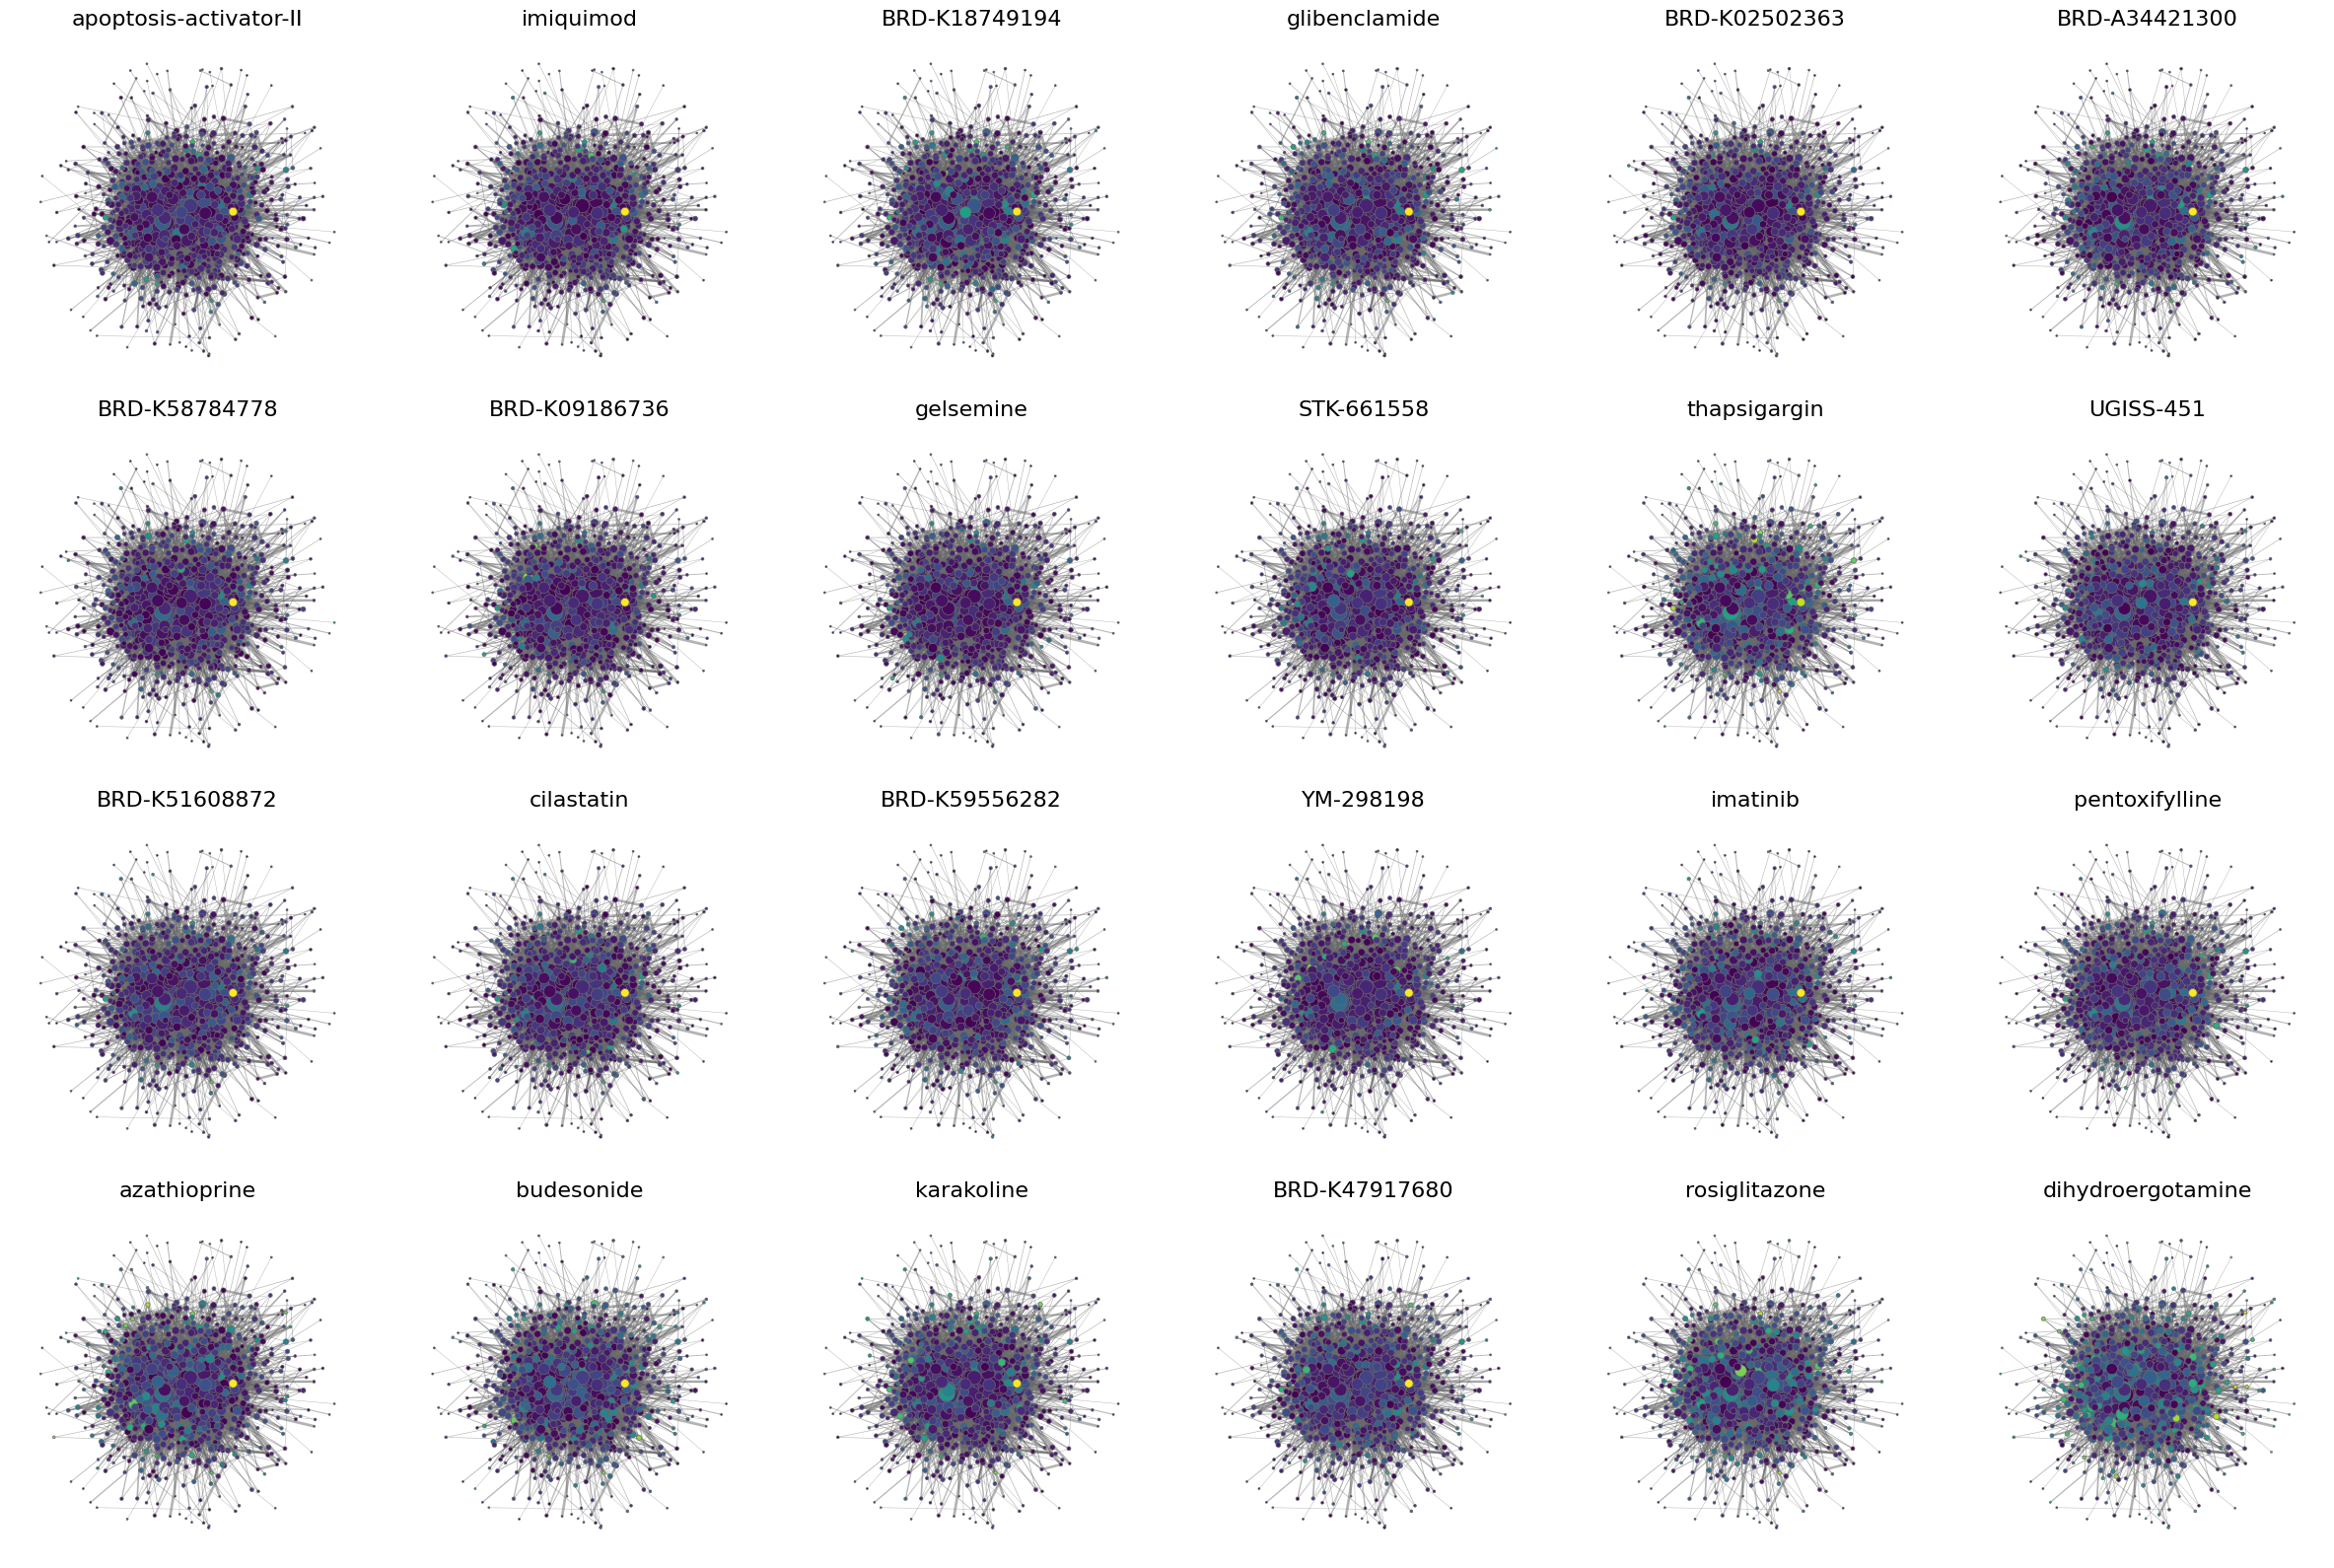

In [217]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')
# Load reference graph
graph_mef = pickle_load(CONTEXT + 'HT29_BRD-K40645748_10_6H.pkl')
# Generate positional data
pos = nx.spring_layout(graph_mef, k = 2)
# Get edge weights
weights = graph_edge_weights(G, modifier = 500)
# Get node degrees
degrees = [nx.degree(graph_mef, node) * 2 for node in graph_mef.nodes]
# Get nodelist
nodelist = [node for node in graph_mef.nodes]

# Get sorted_abs_names
list_abs_sorted_names = [df_lincs_perturbagens['perturbagen_name'][df_lincs_perturbagens['perturbagen_id'] == id].values[0] for id in list_abs_sorted_ids]

# Initialise plot
fig, axes = plt.subplots(4, 6, figsize = (24,16))
plt.subplots_adjust(wspace = 0.05, hspace = 0.05)

for idx, (id, label, ax) in enumerate(zip(list_abs_sorted_ids, list_abs_sorted_names, axes.flat)):

    # Load graph
    G = pickle_load(CONTEXT + f'HT29_{id}_10_6H.pkl')

    # Get abs values for perturbagen
    df_attr = df_abs[[id]]
    # Convert to dictionary
    df_attr_dict = df_attr.to_dict(orient = 'index')
    # Assign node attributes
    nx.set_node_attributes(G, df_attr_dict)
    # Get attribute values
    list_attr = [G.nodes[node][id] for node in G.nodes]

    ax.axis('off')
    ax.set_aspect('equal')

    # Draw edges
    nx.draw_networkx_edges(graph_mef, pos = pos, width = weights, edge_color = 'dimgrey', alpha = 0.5, ax = ax)
    # Draw nodes
    nx.draw_networkx_nodes(G, pos = pos, node_size = degrees, node_color = list_attr, cmap = 'viridis', edgecolors = 'dimgrey', linewidths = 0.5, ax = ax)
    # Set title
    ax.set_title(label, fontsize = 16)

plt.tight_layout()
plt.show()